# Customer Segmentation for a UK Online Retailer
## RFM Analysis, K-Means Clustering, and Quartile Scoring

**Business context.** The data comes from a UK-based, online-only retailer selling unique all-occasion giftware. Most customers are wholesalers. The dataset covers every transaction between 2010-12-01 and 2011-12-09.

**Problem.** Marketing currently treats the customer base as a single list: every customer receives the same campaign at the same frequency. There is no view of which customers are worth a retention budget, which are new and worth developing, and which have already churned.

**Goal.** Build a customer-level segmentation from transaction history alone that marketing can act on:

1. Compute **Recency, Frequency, Monetary (RFM)** for every customer.
2. Segment customers three ways and compare them:
   - the classic **8-segment RFM grid** (mean split),
   - **K-Means clustering** on standardised RFM features (with DBSCAN as a robustness check),
   - a finer **quartile-based RFM score** (1–4 per dimension).
3. Quantify what each segment is worth (customer share vs. revenue share) and recommend an action per segment.

**Notebook structure**

| § | Section | Output |
|---|---|---|
| 1 | Setup and data loading | raw dataframe |
| 2 | Data understanding | data-quality findings that drive cleaning decisions |
| 3 | Cleaning | cleaning funnel table |
| 4 | RFM table | one row per customer |
| 5 | Segmentation A — classic 8-segment grid | `rfm_label` |
| 6 | Segmentation B — K-Means (+ DBSCAN check) | `cluster` |
| 7 | Segmentation C — quartile RFM score | `RFMScore`, `Total_score`, `segment` |
| 8 | Comparing the three approaches | cross-tabs |
| 9 | SQL implementation and parity check | assertion that SQL == pandas |
| 10 | Business summary and export | `rfm_segments.csv` |

## 1. Setup

Run this notebook either **locally** (launch Jupyter from the `notebooks/` folder) or in **Google Colab** (put the whole project folder in your Drive at `MyDrive/DS_Project_Portfolio/rfm-customer-segmentation/`; the next cell mounts Drive automatically). Expected layout:

```
rfm-customer-segmentation/
├── data/online_retail.csv      # the raw file
├── figures/                    # created automatically
├── notebooks/rfm_analysis.ipynb
└── README.md
```

In [36]:
import os
import sqlite3

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

# --- paths ---------------------------------------------------------------
# Works in two environments without edits:
#   * Google Colab : mounts Drive and expects the project folder at
#                    MyDrive/DS_Project_Portfolio/rfm-customer-segmentation/
#   * Local Jupyter: expects to be launched from the notebooks/ folder
try:
    from google.colab import drive          # only importable inside Colab
    drive.mount("/content/drive")
    PROJECT_DIR = "/content/drive/MyDrive/DS_Project_Portfolio/rfm-customer-segmentation"
except ImportError:
    PROJECT_DIR = ".."

DATA_PATH = os.path.join(PROJECT_DIR, "data", "online_retail.csv")
FIG_DIR   = os.path.join(PROJECT_DIR, "figures")
OUT_DIR   = os.path.join(PROJECT_DIR, "outputs")
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

assert os.path.exists(DATA_PATH), f"Data file not found at {DATA_PATH} - see the folder layout above."
print("Project folder:", PROJECT_DIR)

# --- display / plotting defaults ------------------------------------------
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", "{:,.2f}".format)
sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42

def save_fig(name):
    # Save the current figure to FIG_DIR so the README can reference it.
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"{name}.png"), bbox_inches="tight")
    plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project folder: /content/drive/MyDrive/DS_Project_Portfolio/rfm-customer-segmentation


In [37]:
# The file is Latin-1 encoded (product descriptions contain characters such as "é").
# Reading it as UTF-8 raises a UnicodeDecodeError.
df_raw = pd.read_csv(DATA_PATH, encoding="ISO-8859-1")

# InvoiceNo mixes integers and strings ("C536379" for cancellations). Force string
# so that .str methods behave consistently.
df_raw["InvoiceNo"] = df_raw["InvoiceNo"].astype(str)
df_raw["StockCode"] = df_raw["StockCode"].astype(str)

print(f"Raw shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
df_raw.head()

Raw shape: 541,909 rows x 8 columns


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,"17,850.00",United Kingdom


## 2. Data understanding

Before cleaning anything, we need to know what is in the data. Each finding here maps to a cleaning decision in Section 3.

Column dictionary (from the data provider):

| Column | Type | Meaning |
|---|---|---|
| `InvoiceNo` | nominal | 6-digit invoice number. A leading `C` marks a **cancellation** |
| `StockCode` | nominal | 5-digit product code |
| `Description` | nominal | product name |
| `Quantity` | numeric | units per line item |
| `InvoiceDate` | datetime | invoice date and time |
| `UnitPrice` | numeric | price per unit in GBP (£) |
| `CustomerID` | nominal | 5-digit customer number |
| `Country` | nominal | customer's country |

In [38]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [39]:
# 2.1 Missing values ---------------------------------------------------------
missing = (df_raw.isna().sum()
           .to_frame("missing_rows")
           .assign(missing_pct=lambda t: 100 * t["missing_rows"] / len(df_raw))
           .query("missing_rows > 0"))
missing

,missing_rows,missing_pct
Description,1454,0.27
CustomerID,135080,24.93


**Finding 1 — a quarter of rows have no customer.** `CustomerID` is missing on ~25% of rows. RFM is a customer-level metric, so these rows cannot contribute to any customer's score. The question is whether dropping them biases the sample. If the missing rows were clustered in a few weeks, that would suggest a logging outage; if they are spread across the whole period, that is consistent with guest checkout. We check below.

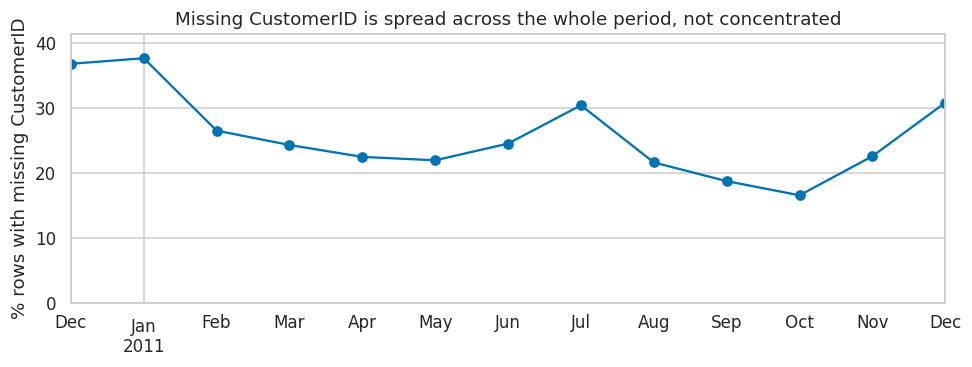

In [40]:
# Where in time are the missing CustomerIDs? Plot the share of rows with a missing
# customer per month. A flat line means guest checkout, not a logging gap.
tmp = df_raw.assign(
    InvoiceDate=pd.to_datetime(df_raw["InvoiceDate"], format="%m/%d/%Y %H:%M"),
    missing_customer=df_raw["CustomerID"].isna(),
)
monthly_missing = (tmp.set_index("InvoiceDate")
                      .resample("MS")["missing_customer"]
                      .mean() * 100)

fig, ax = plt.subplots(figsize=(9, 3.5))
monthly_missing.plot(ax=ax, marker="o")
ax.set_ylabel("% rows with missing CustomerID")
ax.set_xlabel("")
ax.set_title("Missing CustomerID is spread across the whole period, not concentrated")
ax.set_ylim(0, max(40, monthly_missing.max() * 1.1))
save_fig("01_missing_customer_by_month")

In [41]:
# 2.2 Cancellations, negative quantities, zero prices
is_cancel   = df_raw["InvoiceNo"].str.startswith("C")
neg_qty     = df_raw["Quantity"] <= 0
zero_price  = df_raw["UnitPrice"] <= 0

print(f"Cancellation invoices (InvoiceNo starts with 'C'): {is_cancel.sum():>7,}")
print(f"Rows with Quantity <= 0:                            {neg_qty.sum():>7,}")
print(f"  ...of which are cancellations:                    {(neg_qty & is_cancel).sum():>7,}")
print(f"Rows with UnitPrice <= 0:                           {zero_price.sum():>7,}")
print(f"Exact duplicate rows:                               {df_raw.duplicated().sum():>7,}")
print()
print("Quantity range :", df_raw["Quantity"].min(), "to", df_raw["Quantity"].max())
print("UnitPrice range:", df_raw["UnitPrice"].min(), "to", df_raw["UnitPrice"].max())

Cancellation invoices (InvoiceNo starts with 'C'):   9,288
Rows with Quantity <= 0:                             10,624
  ...of which are cancellations:                      9,288
Rows with UnitPrice <= 0:                             2,517
Exact duplicate rows:                                 5,268

Quantity range : -80995 to 80995
UnitPrice range: -11062.06 to 38970.0


**Finding 2 — returns are encoded as cancellation invoices with negative quantities.** The `Quantity` range is symmetric (−80,995 to +80,995): that is one very large order and its full reversal. Netting returns against purchases is the right thing for a revenue report, but here Monetary is meant as a proxy for *purchase intent*. A customer who ordered £80K and then returned it still demonstrated engagement, so we drop the cancellation rows rather than subtract them.

**Finding 3 — negative quantities that are *not* cancellations** (a few hundred rows) are stock adjustments with no customer attached; they disappear when we drop missing `CustomerID`.

**Finding 4 — exact duplicate rows** (~5K). Same invoice, product, quantity, price, timestamp. These are almost certainly double-entered lines, not two separate purchases. We drop them; keeping them would inflate Monetary slightly.

In [42]:
# 2.3 Non-product rows ------------------------------------------------------
# Product codes are 5 digits (optionally followed by a letter, e.g. 85123A).
# Anything else is a service or accounting line.
is_product = df_raw["StockCode"].str.match(r"^\d{5}")
non_product = df_raw.loc[~is_product, ["StockCode", "Description"]]

print("Non-product StockCodes and how often they appear:")
print(non_product["StockCode"].value_counts().head(10))
print()
print("Highest unit prices in the data:")
df_raw.nlargest(5, "UnitPrice")[["StockCode", "Description", "Quantity", "UnitPrice"]]

Non-product StockCodes and how often they appear:
StockCode
POST            1256
DOT              710
M                571
C2               144
D                 77
S                 63
BANK CHARGES      37
AMAZONFEE         34
CRUK              16
DCGSSGIRL         13
Name: count, dtype: int64

Highest unit prices in the data:


,StockCode,Description,Quantity,UnitPrice
222681,M,Manual,-1,"38,970.00"
524602,AMAZONFEE,AMAZON FEE,-1,"17,836.46"
43702,AMAZONFEE,AMAZON FEE,-1,"16,888.02"
43703,AMAZONFEE,AMAZON FEE,-1,"16,453.71"
15016,AMAZONFEE,AMAZON FEE,-1,"13,541.33"


**Finding 5 — postage, manual adjustments and bank charges sit alongside products.** `POST` (postage), `M` (manual), `DOT` (dotcom postage), `BANK CHARGES`. The five highest "unit prices" are all such lines, not products. **Decision: keep them in Monetary.** Postage a customer paid is real revenue to this business, and the amounts are small relative to product revenue (checked in Section 3). They should, however, be excluded from any *product-level* analysis.

In [43]:
# 2.4 Product code vs. description consistency ------------------------------
n_codes = df_raw["StockCode"].nunique()
n_desc  = df_raw["Description"].nunique()
print(f"Unique StockCode   : {n_codes:,}")
print(f"Unique Description : {n_desc:,}")
print(f"Descriptions exceed codes by {n_desc - n_codes:,} -> the same product is described inconsistently.")

# Example of one product with several spellings
example = (df_raw.groupby("StockCode")["Description"].nunique()
                 .sort_values(ascending=False).head(1).index[0])
df_raw.loc[df_raw["StockCode"] == example, "Description"].value_counts().head()

Unique StockCode   : 4,070
Unique Description : 4,223
Descriptions exceed codes by 153 -> the same product is described inconsistently.


,count
Description,
JUMBO BAG OWLS,673
wrongly marked. 23343 in box,1
wrongly coded-23343,1
found,1
Found,1


**Finding 6 — one product, several descriptions.** This does not affect RFM (we never group by description), but it is a data-quality flag for any future product analysis: always key on `StockCode`, never on `Description`.

In [44]:
# 2.5 Geography --------------------------------------------------------------
country_share = (df_raw["Country"].value_counts(normalize=True) * 100).head(10)
print(f"{df_raw['Country'].nunique()} countries in total. Top 10 by row share (%):")
country_share.round(2)

38 countries in total. Top 10 by row share (%):


,proportion
Country,
United Kingdom,91.43
Germany,1.75
France,1.58
EIRE,1.51
Spain,0.47
Netherlands,0.44
Belgium,0.38
Switzerland,0.37
Portugal,0.28


## 3. Cleaning

Each step is applied in order and logged, so the final table shows exactly how many rows each decision removed.

In [45]:
funnel = []
def log_step(name, frame):
    # Append (step name, rows remaining) to the cleaning funnel.
    funnel.append((name, len(frame)))
    return frame

df = log_step("Raw", df_raw.copy())

# Step 1: drop rows with no customer (cannot be attributed; see Finding 1)
df = log_step("Drop missing CustomerID", df.dropna(subset=["CustomerID"]))

# Step 2: drop exact duplicate rows (double-entered lines; see Finding 4)
df = log_step("Drop exact duplicates", df.drop_duplicates())

# Step 3: drop cancellation invoices (returns; see Finding 2)
df = log_step("Drop cancellations ('C' invoices)", df[~df["InvoiceNo"].str.startswith("C")])

# Step 4: keep only positive quantity and price (removes zero-price giveaways / adjustments)
df = log_step("Drop Quantity<=0 or UnitPrice<=0", df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)])

# Type fixes
df["CustomerID"]  = df["CustomerID"].astype(int)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], format="%m/%d/%Y %H:%M")
df["Revenue"]     = df["Quantity"] * df["UnitPrice"]     # line-item revenue in GBP

# Cleaning funnel
funnel_df = pd.DataFrame(funnel, columns=["step", "rows_remaining"])
funnel_df["rows_removed"] = -funnel_df["rows_remaining"].diff().fillna(0).astype(int)
funnel_df["pct_of_raw_removed"] = (100 * funnel_df["rows_removed"] / len(df_raw)).round(2)
funnel_df

,step,rows_remaining,rows_removed,pct_of_raw_removed
0,Raw,541909,0,0.00
1,Drop missing CustomerID,406829,135080,24.93
2,Drop exact duplicates,401604,5225,0.96
3,Drop cancellations ('C' invoices),392732,8872,1.64
4,Drop Quantity<=0 or UnitPrice<=0,392692,40,0.01


In [46]:
print(f"Clean transactions : {len(df):,}")
print(f"Unique customers   : {df['CustomerID'].nunique():,}")
print(f"Unique invoices    : {df['InvoiceNo'].nunique():,}")
print(f"Date range         : {df['InvoiceDate'].min().date()} to {df['InvoiceDate'].max().date()}")
print(f"Total revenue      : £{df['Revenue'].sum():,.0f}")

non_product_rev = df.loc[~df["StockCode"].str.match(r"^\d{5}"), "Revenue"].sum()
print(f"  of which non-product lines (postage etc.): £{non_product_rev:,.0f} "
      f"({100 * non_product_rev / df['Revenue'].sum():.1f}%) -> kept, immaterial")

Clean transactions : 392,692
Unique customers   : 4,338
Unique invoices    : 18,532
Date range         : 2010-12-01 to 2011-12-09
Total revenue      : £8,887,209
  of which non-product lines (postage etc.): £149,981 (1.7%) -> kept, immaterial


## 4. Building the RFM table

One row per customer with three numbers:

| Metric | Definition | Why this definition |
|---|---|---|
| **Recency** | days between the customer's last invoice and the snapshot date | Snapshot = last date in the data **+ 1 day**, so a customer who bought on the final day gets Recency = 1, not 0. |
| **Frequency** | number of **distinct invoices** | Counting line items would measure basket breadth, not purchase occasions. A wholesaler buying 40 products once is not more loyal than one buying 2 products on 10 occasions. |
| **Monetary** | sum of `Quantity × UnitPrice` | Gross revenue contributed over the period. |

In [47]:
snapshot_date = df["InvoiceDate"].max().normalize() + pd.Timedelta(days=1)
print("Snapshot date:", snapshot_date.date())

rfm = (df.groupby("CustomerID")
         .agg(last_purchase=("InvoiceDate", "max"),
              Frequency=("InvoiceNo", "nunique"),     # distinct orders, not line items
              Monetary=("Revenue", "sum"))
         .reset_index())

# Recency in whole days. Normalise both sides to midnight so time-of-day does not matter.
rfm["Recency"] = (snapshot_date - rfm["last_purchase"].dt.normalize()).dt.days

rfm = rfm[["CustomerID", "Recency", "Frequency", "Monetary"]].set_index("CustomerID")
rfm.head()

Snapshot date: 2011-12-10


,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,"77,183.60"
12347,3,7,"4,310.00"
12348,76,4,"1,797.24"
12349,19,1,"1,757.55"
12350,311,1,334.40


In [48]:
rfm.describe().T

,count,mean,std,min,25%,50%,75%,max
Recency,"4,338.00",93.06,100.01,1.00,18.00,51.00,142.75,374.00
Frequency,"4,338.00",4.27,7.70,1.00,1.00,2.00,5.00,209.00
Monetary,"4,338.00","2,048.69","8,985.23",3.75,306.48,668.57,"1,660.60","280,206.02"


Two things stand out in the summary and both shape everything that follows:

- **All three metrics are heavily right-skewed.** Median Monetary is ~£670 but the mean is ~£2,000 and the maximum is ~£280K. Any distance-based method (K-Means) must be run on transformed features, otherwise Monetary dominates.
- **The median customer has placed only 2 orders, and the 25th percentile is 1.** A large share of the base has never bought a second time. That reframes the business problem: this is as much a *first-to-second-purchase* problem as a retention problem.

Customers with exactly one order: 34.4%


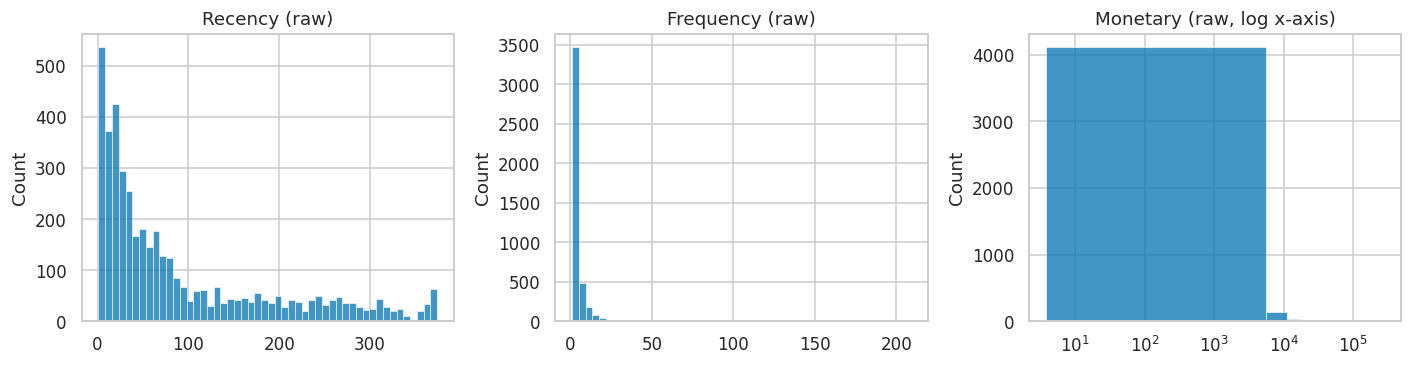

In [49]:
one_time = (rfm["Frequency"] == 1).mean() * 100
print(f"Customers with exactly one order: {one_time:.1f}%")

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, col in zip(axes, ["Recency", "Frequency", "Monetary"]):
    sns.histplot(rfm[col], bins=50, ax=ax)
    ax.set_title(f"{col} (raw)")
    ax.set_xlabel("")
axes[2].set_xscale("log")
axes[2].set_title("Monetary (raw, log x-axis)")
save_fig("02_rfm_distributions")

Revenue share of the top ... customers by spend:
  top   5% of customers ->  50.4% of revenue
  top  10% of customers ->  61.4% of revenue
  top  20% of customers ->  74.7% of revenue
  top  50% of customers ->  92.2% of revenue


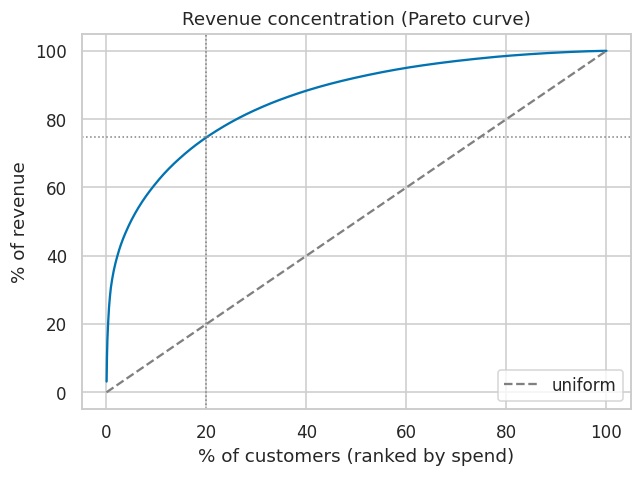

In [50]:
# How concentrated is revenue? Pareto curve: cumulative revenue vs. cumulative customers.
sorted_m = rfm["Monetary"].sort_values(ascending=False)
cum_rev  = sorted_m.cumsum() / sorted_m.sum()
cum_cust = np.arange(1, len(sorted_m) + 1) / len(sorted_m)

def revenue_share_of_top(pct):
    return cum_rev.iloc[int(len(sorted_m) * pct) - 1] * 100

print("Revenue share of the top ... customers by spend:")
for p in [0.05, 0.10, 0.20, 0.50]:
    print(f"  top {p:>4.0%} of customers -> {revenue_share_of_top(p):5.1f}% of revenue")

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(cum_cust * 100, cum_rev * 100)
ax.plot([0, 100], [0, 100], linestyle="--", color="grey", label="uniform")
ax.axvline(20, color="grey", linestyle=":", lw=1)
ax.axhline(revenue_share_of_top(0.20), color="grey", linestyle=":", lw=1)
ax.set_xlabel("% of customers (ranked by spend)")
ax.set_ylabel("% of revenue")
ax.set_title("Revenue concentration (Pareto curve)")
ax.legend()
save_fig("03_pareto_curve")

## 5. Segmentation A — the classic 8-segment RFM grid

The textbook RFM method splits each dimension into **high / low at the mean**, giving 2³ = 8 cells. Each cell has a conventional name that tells marketing what to do.

Encoding used here: each dimension gets `1` if the customer is **above** the population mean, else `0`. Because a *high* Recency value means a *long time since the last purchase*, the direction of R is the opposite of F and M:

| Code (R F M) | Recency | Frequency | Monetary | Segment | Typical action |
|---|---|---|---|---|---|
| `0 1 1` | recent | high | high | **Champions** (重要价值) | reward, early access |
| `1 1 1` | lapsed | high | high | **Loyal at risk** (重要保持) | win back before they leave |
| `0 0 1` | recent | low | high | **Big new spenders** (重要发展) | develop into repeat buyers |
| `1 0 1` | lapsed | low | high | **High-value lost** (重要挽留) | targeted reactivation |
| `0 1 0` | recent | high | low | **Frequent low spenders** (一般价值) | upsell |
| `1 1 0` | lapsed | high | low | **Lapsed regulars** (一般保持) | light-touch reminder |
| `0 0 0` | recent | low | low | **New / promising** (一般发展) | onboarding, second-purchase offer |
| `1 0 0` | lapsed | low | low | **Lost low value** (一般挽留) | suppress from paid campaigns |

> Note on the R direction: getting this backwards is the most common mistake in RFM implementations. With the encoding above, `0` in the R position always means *good* (recent), so the two "value" segments are `011` and `111`, not `111` and `011`.

In [51]:
RFM_COLS = ["Recency", "Frequency", "Monetary"]

# z-score each dimension, then flag 1 if above the mean (z > 0), else 0
z = (rfm[RFM_COLS] - rfm[RFM_COLS].mean()) / rfm[RFM_COLS].std()
rfm["rfm_code"] = (z > 0).astype(int).astype(str).agg("".join, axis=1)   # e.g. "011"

SEGMENT_NAMES = {
    "011": "Champions",
    "111": "Loyal at risk",
    "001": "Big new spenders",
    "101": "High-value lost",
    "010": "Frequent low spenders",
    "110": "Lapsed regulars",
    "000": "New / promising",
    "100": "Lost low value",
}
rfm["rfm_label"] = rfm["rfm_code"].map(SEGMENT_NAMES)

rfm.head()

,Recency,Frequency,Monetary,rfm_code,rfm_label
CustomerID,,,,,
12346,326,1,"77,183.60",101,High-value lost
12347,3,7,"4,310.00",011,Champions
12348,76,4,"1,797.24",000,New / promising
12349,19,1,"1,757.55",000,New / promising
12350,311,1,334.40,100,Lost low value


In [52]:
def segment_summary(frame, by):
    # Size, revenue share and median R/F/M per segment. Reused for all three methods.
    out = (frame.groupby(by)
                .agg(customers=("Monetary", "size"),
                     revenue=("Monetary", "sum"),
                     median_recency=("Recency", "median"),
                     median_frequency=("Frequency", "median"),
                     median_monetary=("Monetary", "median")))
    out["customer_share_%"] = 100 * out["customers"] / out["customers"].sum()
    out["revenue_share_%"]  = 100 * out["revenue"] / out["revenue"].sum()
    return out.sort_values("revenue_share_%", ascending=False)

grid_summary = segment_summary(rfm, "rfm_label")
grid_summary

,customers,revenue,median_recency,median_frequency,median_monetary,customer_share_%,revenue_share_%
rfm_label,,,,,,,
Champions,689,"5,686,656.77",12.00,10.00,"3,902.28",15.88,63.99
New / promising,1750,"1,113,981.88",34.00,2.00,527.12,40.34,12.53
Lost low value,1319,"590,599.73",214.00,1.00,321.43,30.41,6.65
Big new spenders,117,"577,359.25",32.00,3.00,"2,876.01",2.70,6.50
Frequent low spenders,358,"493,688.07",18.00,6.00,"1,416.69",8.25,5.56
High-value lost,38,"272,798.72",149.00,3.00,"2,865.82",0.88,3.07
Loyal at risk,27,"106,643.54",127.00,8.00,"3,344.64",0.62,1.20
Lapsed regulars,40,"45,480.93",136.00,5.00,"1,108.80",0.92,0.51


**What the grid tells us, and where it falls short.**

The grid is easy to explain and the actions per cell are self-evident. But a split at the mean has two problems on skewed data:

- **It is very unbalanced.** Roughly 70% of customers collapse into just two cells (`000` and `100`), while the three "lapsed but valuable" cells (`111`, `101`, `110`) hold only a few dozen customers each. Marketing cannot build a programme around a segment of 27 people.
- **It is coarse.** Two levels per dimension treat a customer 1 day above the mean Recency and one 300 days above it identically.

Two ways to do better: let the data choose the boundaries (**K-Means**, Section 6), or keep the rule-based logic but use finer bins (**quartiles**, Section 7).

## 6. Segmentation B — K-Means clustering

### 6.1 Feature preparation

K-Means minimises Euclidean distance, so two things are required before fitting:

1. **Log-transform** each feature. R, F and M are all right-skewed; on the raw scale a single £280K customer would pull a cluster centre toward itself.
2. **Standardise** to zero mean and unit variance. Without this, Monetary (range 0–280,000) dominates Recency (range 1–374) and Frequency (range 1–200) completely, and the "clusters" are just spend bands.

In [53]:
X_log    = np.log1p(rfm[RFM_COLS])           # log(1 + x): handles Frequency = 1 gracefully
scaler   = StandardScaler().fit(X_log)
X_scaled = pd.DataFrame(scaler.transform(X_log), index=rfm.index, columns=RFM_COLS)

X_scaled.describe().T[["mean", "std", "min", "max"]]

,mean,std,min,max
Recency,0.00,1.00,-2.42,1.58
Frequency,-0.00,1.00,-0.96,5.86
Monetary,-0.00,1.00,-4.00,4.73


### 6.2 Choosing the number of clusters

Two diagnostics for k = 2 … 10:

- **Elbow (inertia)** — within-cluster sum of squares. A sharp bend suggests a natural k; a smooth curve suggests the data is a continuum.
- **Silhouette score** — how much closer each point is to its own cluster than to the nearest other cluster (range −1 to 1; higher is better).

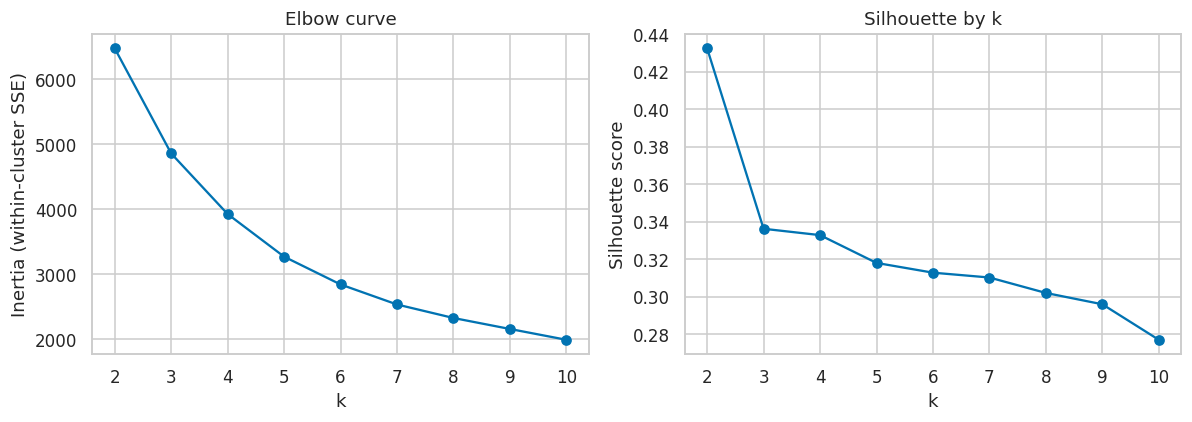

,k,inertia,silhouette
0,2,"6,476.51",0.43
1,3,"4,858.24",0.34
2,4,"3,925.43",0.33
3,5,"3,269.28",0.32
4,6,"2,841.42",0.31
5,7,"2,532.99",0.31
6,8,"2,325.07",0.30
7,9,"2,156.02",0.30
8,10,"1,989.40",0.28


In [54]:
k_range = range(2, 11)
inertia, silhouette = [], []
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_scaled)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(list(k_range), inertia, marker="o")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia (within-cluster SSE)")
axes[0].set_title("Elbow curve")
axes[1].plot(list(k_range), silhouette, marker="o")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette by k")
save_fig("04_kmeans_k_selection")

pd.DataFrame({"k": list(k_range), "inertia": inertia, "silhouette": silhouette}).round(3)

**Reading the diagnostics honestly.** The silhouette peaks at k = 2 and then decays smoothly; the elbow curve has no sharp bend. Both say the same thing: RFM space for this business is a **continuum with a long tail, not a set of well-separated groups**. Any k we pick is a management convention, not a discovery.

Given that, the choice of k is a business decision. k = 2 only separates "active" from "lapsed", which is too coarse to act on. **k = 3** is the smallest value that produces three tiers with clearly different behaviour and revenue contribution (shown below), and maps onto a Platinum / Gold / Silver programme that marketing can operate. We use k = 3 and state that reasoning rather than pretending the elbow chose it.

In [55]:
K = 3
kmeans = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_STATE).fit(X_scaled)
rfm["cluster"] = kmeans.labels_

# Cluster ids from K-Means are arbitrary. Re-label them by median Monetary so that
# 0 = highest value, 1 = middle, 2 = lowest. This makes the rest of the notebook readable.
order = rfm.groupby("cluster")["Monetary"].median().sort_values(ascending=False).index
rank  = {old: new for new, old in enumerate(order)}
rfm["cluster"] = rfm["cluster"].map(rank)

CLUSTER_NAMES = {0: "Platinum", 1: "Gold", 2: "Silver"}
rfm["cluster_name"] = rfm["cluster"].map(CLUSTER_NAMES)

kmeans_summary = segment_summary(rfm, "cluster_name")
kmeans_summary

,customers,revenue,median_recency,median_frequency,median_monetary,customer_share_%,revenue_share_%
cluster_name,,,,,,,
Platinum,775,"6,106,996.99",10.00,10.00,"3,701.44",17.87,68.72
Gold,1697,"2,103,762.82",30.00,3.00,962.19,39.12,23.67
Silver,1866,"676,449.08",160.00,1.00,296.09,43.02,7.61


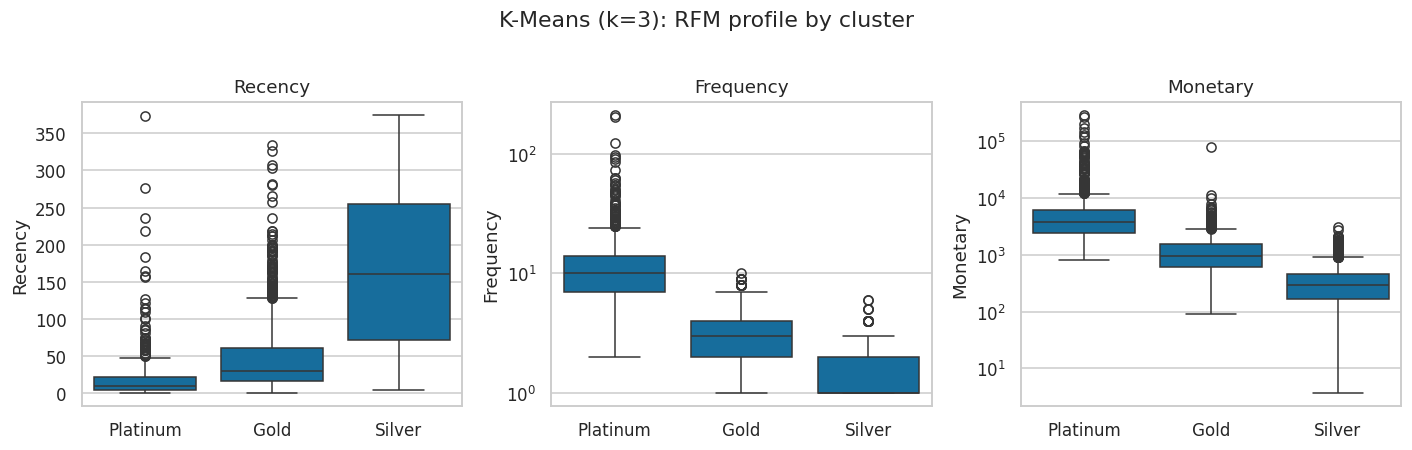

In [56]:
# Distribution of each RFM metric by cluster. Log y-axis for Frequency and Monetary
# so that the boxes are readable despite the long tails.
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col in zip(axes, RFM_COLS):
    sns.boxplot(data=rfm, x="cluster_name", y=col, order=["Platinum", "Gold", "Silver"], ax=ax)
    ax.set_xlabel("")
    ax.set_title(col)
axes[1].set_yscale("log"); axes[2].set_yscale("log")
fig.suptitle("K-Means (k=3): RFM profile by cluster", y=1.02)
save_fig("05_kmeans_cluster_profiles")

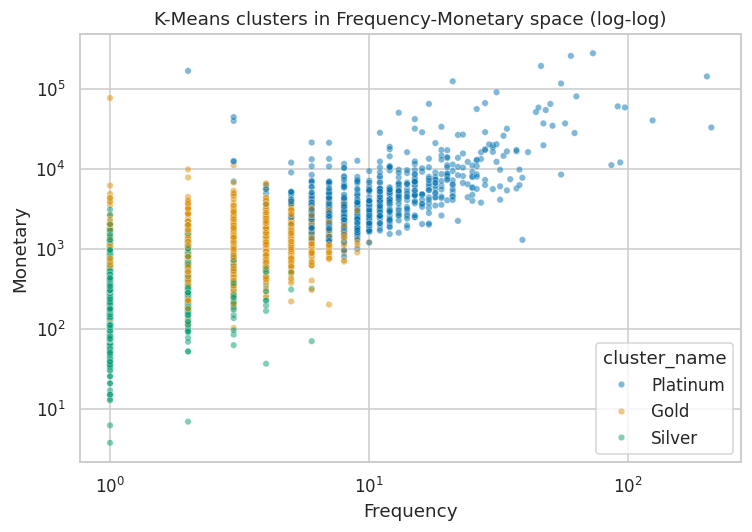

In [57]:
# 2-D view: Frequency vs Monetary (log-log), coloured by cluster, point size = recency.
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=rfm, x="Frequency", y="Monetary", hue="cluster_name",
                hue_order=["Platinum", "Gold", "Silver"], alpha=0.5, s=18, ax=ax)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_title("K-Means clusters in Frequency-Monetary space (log-log)")
save_fig("06_kmeans_scatter")

### 6.3 Robustness check — DBSCAN

K-Means will always return k clusters, even on data with no cluster structure. DBSCAN is density-based and is free to return any number of clusters, or none. Running it on the same standardised features tests whether the three K-Means tiers correspond to anything real.

`eps` is chosen from the k-distance plot (distance to the 5th nearest neighbour, sorted): the "knee" of that curve is the density threshold that separates the dense core from sparse points.

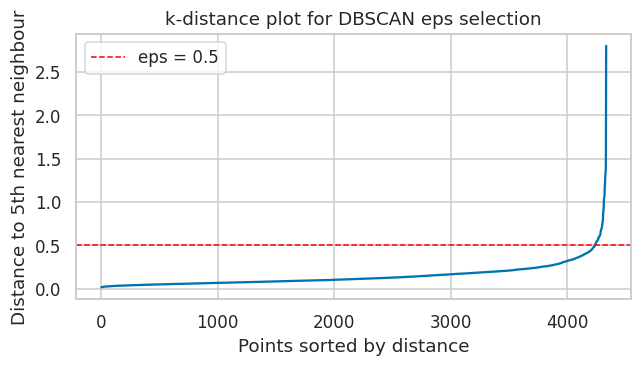

In [58]:
MIN_SAMPLES = 5   # rule of thumb: 2 * n_features - 1

nn = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_scaled)
dist, _ = nn.kneighbors(X_scaled)
k_dist = np.sort(dist[:, -1])

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(k_dist)
ax.set_xlabel("Points sorted by distance")
ax.set_ylabel(f"Distance to {MIN_SAMPLES}th nearest neighbour")
ax.set_title("k-distance plot for DBSCAN eps selection")
ax.axhline(0.5, color="red", linestyle="--", lw=1, label="eps = 0.5")
ax.legend()
save_fig("07_dbscan_kdistance")

In [59]:
EPS = 0.5
dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES).fit(X_scaled)
rfm["dbscan"] = dbscan.labels_          # -1 = noise (does not belong to any dense region)

n_clusters = len(set(rfm["dbscan"])) - (1 if -1 in rfm["dbscan"].values else 0)
print(f"DBSCAN (eps={EPS}, min_samples={MIN_SAMPLES}): {n_clusters} clusters, "
      f"{(rfm['dbscan'] == -1).sum()} noise points")

segment_summary(rfm, "dbscan")

DBSCAN (eps=0.5, min_samples=5): 2 clusters, 62 noise points


,customers,revenue,median_recency,median_frequency,median_monetary,customer_share_%,revenue_share_%
dbscan,,,,,,,
0,2791,"5,643,262.79",31.00,4.00,"1,131.56",64.34,63.50
-1,62,"2,718,122.05",9.50,15.50,"28,227.21",1.43,30.58
1,1485,"525,824.05",134.00,1.00,255.91,34.23,5.92


**Interpretation.** DBSCAN finds one large dense region containing most customers, a second region of lapsed one-time buyers, and flags a few dozen customers as "noise". Those noise points are not errors: they are the highest-spending accounts in the business, isolated because there are too few of them to form a dense region. This confirms the K-Means reading — the base is a continuum plus a thin, extremely valuable tail — and gives a concrete list of accounts that deserve named account management rather than automated campaigns.

## 7. Segmentation C — quartile RFM score

Back to a rule-based method, but with finer bins. Each dimension is scored **1 to 4 by quartile, where 1 is always best**:

- Recency: **lowest** quartile (most recent) → 1
- Frequency and Monetary: **highest** quartile → 1

Keeping the direction consistent means a composite score is interpretable: 3 is the best possible customer, 12 the worst.

The quartile boundaries are computed once and stored. In production they should be frozen from a reference period so that a customer's score does not change just because the population shifted.

In [60]:
quartiles = rfm[RFM_COLS].quantile([0.25, 0.50, 0.75])
quartiles

,Recency,Frequency,Monetary
0.25,18.00,1.00,306.48
0.50,51.00,2.00,668.57
0.75,142.75,5.00,"1,660.60"


In [61]:
def r_score(x, q):
    # Recency: lower is better -> lowest quartile gets 1
    if x <= q[0.25]: return 1
    if x <= q[0.50]: return 2
    if x <= q[0.75]: return 3
    return 4

def fm_score(x, q):
    # Frequency / Monetary: higher is better -> highest quartile gets 1
    if x <= q[0.25]: return 4
    if x <= q[0.50]: return 3
    if x <= q[0.75]: return 2
    return 1

rfm["R_score"] = rfm["Recency"].apply(r_score, q=quartiles["Recency"])
rfm["F_score"] = rfm["Frequency"].apply(fm_score, q=quartiles["Frequency"])
rfm["M_score"] = rfm["Monetary"].apply(fm_score, q=quartiles["Monetary"])

# Two composites:
#   RFMScore   - concatenated, keeps which dimension is weak (e.g. "144" vs "411")
#   Total_score - summed, one orderable number 3..12 (loses that detail: 413 == 431 == 8)
rfm["RFMScore"]    = rfm["R_score"].astype(str) + rfm["F_score"].astype(str) + rfm["M_score"].astype(str)
rfm["Total_score"] = rfm["R_score"] + rfm["F_score"] + rfm["M_score"]

print(f"{rfm['RFMScore'].nunique()} of 64 possible RFMScore combinations are occupied")
rfm[RFM_COLS + ["R_score", "F_score", "M_score", "RFMScore", "Total_score"]].head()

61 of 64 possible RFMScore combinations are occupied


,Recency,Frequency,Monetary,R_score,F_score,M_score,RFMScore,Total_score
CustomerID,,,,,,,,
12346,326,1,"77,183.60",4,4,1,441,9
12347,3,7,"4,310.00",1,1,1,111,3
12348,76,4,"1,797.24",3,2,1,321,6
12349,19,1,"1,757.55",2,4,1,241,7
12350,311,1,334.40,4,4,3,443,11


Note that Frequency quartiles are heavily tied (25% = 1 order, 50% = 2 orders). With `<=` boundaries, every one-time buyer scores F = 4 and every two-time buyer scores F = 3. That is the intended behaviour: it is a fact about the customer base, not a flaw in the scoring.

### 7.1 Validation: does the score actually rank customers?

If `Total_score` is meaningful, mean Recency should rise and mean Frequency / Monetary should fall monotonically as the score goes from 3 to 12.

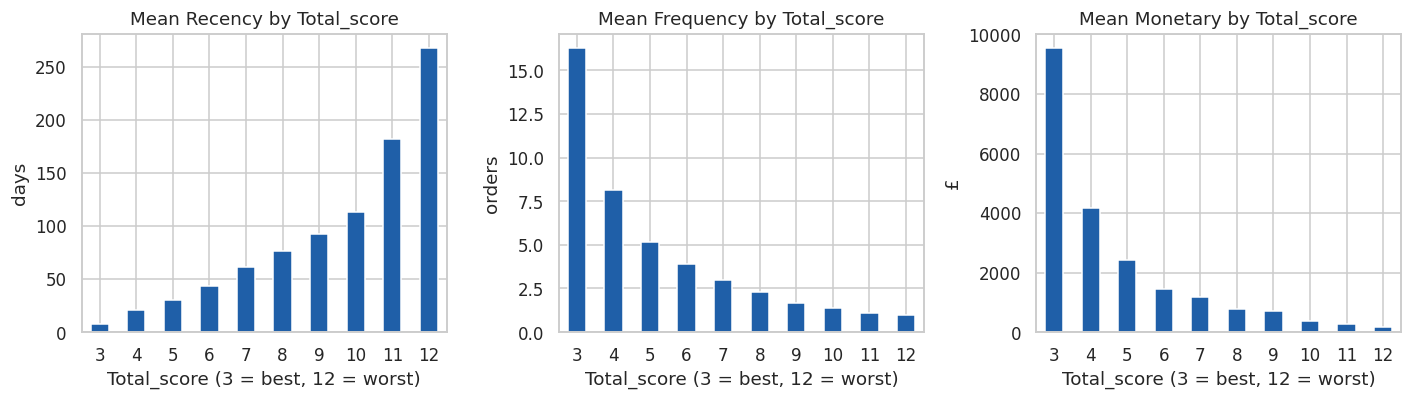

,Recency,Frequency,Monetary
Total_score,,,
3,7.70,16.30,"9,546.50"
4,20.80,8.10,"4,153.50"
5,29.80,5.20,"2,420.40"
6,43.10,3.90,"1,456.20"
7,60.90,3.00,"1,193.80"
8,76.70,2.30,781.50
9,91.90,1.70,713.20
10,112.90,1.40,382.10
11,181.90,1.10,287.00


In [62]:
by_score = rfm.groupby("Total_score")[RFM_COLS].mean()

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, col, ylabel in zip(axes, RFM_COLS, ["days", "orders", "£"]):
    by_score[col].plot(kind="bar", ax=ax, color="#1f5fa8")
    ax.set_title(f"Mean {col} by Total_score")
    ax.set_xlabel("Total_score (3 = best, 12 = worst)")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=0)
save_fig("08_total_score_validation")

by_score.round(1)

All three move monotonically with no inversions. The spread is large: the best-scoring customers average several thousand pounds and a few days since their last order; the worst average under £200 and most of a year.

### 7.2 Named segments

A handful of named, **mutually exclusive** segments built from the scores, assigned in priority order so that every customer lands in exactly one. Definitions:

In [63]:
def assign_segment(row):
    r, f, m = row["R_score"], row["F_score"], row["M_score"]
    if r == 1 and f == 1 and m == 1:           return "Champions"        # best on all three
    if f == 1:                                 return "Loyal"            # top-quartile frequency
    if m == 1:                                 return "Big spenders"     # top-quartile spend, not top frequency
    if r >= 3 and (f <= 2 or m <= 2):          return "At risk"          # used to be good, going quiet
    if r == 4:                                 return "Lost"             # bottom-quartile recency, never strong
    if r == 1:                                 return "Promising"        # recent, still low F and M
    return "Regular"

rfm["segment"] = rfm.apply(assign_segment, axis=1)

SEGMENT_ORDER = ["Champions", "Loyal", "Big spenders", "Promising", "Regular", "At risk", "Lost"]
score_summary = segment_summary(rfm, "segment").loc[SEGMENT_ORDER]
score_summary

,customers,revenue,median_recency,median_frequency,median_monetary,customer_share_%,revenue_share_%
segment,,,,,,,
Champions,455,"4,343,648.75",6.00,11.00,"4,113.68",10.49,48.88
Loyal,417,"1,550,345.26",31.00,7.00,"2,298.93",9.61,17.44
Big spenders,363,"1,321,593.56",43.00,4.00,"2,247.41",8.37,14.87
Promising,486,"333,176.52",10.00,2.00,638.22,11.20,3.75
Regular,1206,"588,722.75",44.00,1.00,392.76,27.80,6.62
At risk,585,"525,369.23",107.00,3.00,855.91,13.49,5.91
Lost,826,"224,352.82",254.00,1.00,243.92,19.04,2.52


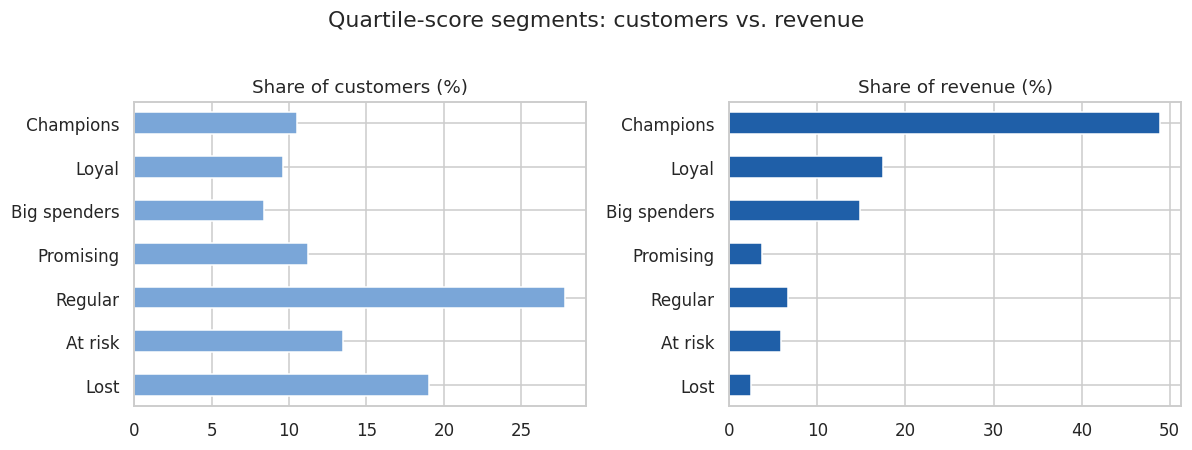

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)
score_summary["customer_share_%"].plot(kind="barh", ax=axes[0], color="#7aa6d8")
axes[0].set_title("Share of customers (%)"); axes[0].invert_yaxis(); axes[0].set_ylabel("")
score_summary["revenue_share_%"].plot(kind="barh", ax=axes[1], color="#1f5fa8")
axes[1].set_title("Share of revenue (%)"); axes[1].invert_yaxis(); axes[1].set_ylabel("")
fig.suptitle("Quartile-score segments: customers vs. revenue", y=1.02)
save_fig("09_segment_customer_vs_revenue")

## 8. Comparing the three approaches

Do the three methods agree on who the valuable customers are? Cross-tabulate K-Means clusters against the other two segmentations.

In [65]:
print("K-Means cluster vs. classic 8-segment grid (row counts)")
pd.crosstab(rfm["cluster_name"], rfm["rfm_label"]).loc[["Platinum", "Gold", "Silver"]]

K-Means cluster vs. classic 8-segment grid (row counts)


rfm_label,Big new spenders,Champions,Frequent low spenders,High-value lost,Lapsed regulars,Lost low value,Loyal at risk,New / promising
cluster_name,,,,,,,,
Platinum,16,621,120,2,0,0,13,3
Gold,101,68,238,33,35,99,14,1109
Silver,0,0,0,3,5,1220,0,638


In [66]:
print("K-Means cluster vs. quartile-score segment (row counts)")
pd.crosstab(rfm["cluster_name"], rfm["segment"]).loc[["Platinum", "Gold", "Silver"], SEGMENT_ORDER]

K-Means cluster vs. quartile-score segment (row counts)


segment,Champions,Loyal,Big spenders,Promising,Regular,At risk,Lost
cluster_name,,,,,,,
Platinum,451,256,57,11,0,0,0
Gold,4,159,289,447,490,308,0
Silver,0,2,17,28,716,277,826


**Summary of the comparison**

| Method | Strengths | Weaknesses | Use it for |
|---|---|---|---|
| 8-segment grid (mean split) | Simplest to explain; action per cell is conventional | Mean is dragged by whales, so cells are very unbalanced; 2 levels per dimension is coarse | Executive summary; a first pass |
| K-Means (k=3) | Data-driven boundaries; balanced tiers; clean Platinum / Gold / Silver story | k is a convention (no real cluster structure); boundaries move when refit; harder to explain a single customer's assignment | Tiered loyalty programme |
| Quartile score | Fine-grained (61 cells); 1 = best in all dimensions; stable if boundaries are frozen; every customer's score is explainable | Ties in Frequency; 64 cells need collapsing into named segments | Campaign targeting and suppression lists |

The three methods largely agree on the extremes: K-Means Platinum is almost entirely Champions / Loyal / Big spenders, and K-Means Silver is almost entirely Lost / At risk. They differ in the middle, which is exactly where the choice of method is a judgement call.

## 9. SQL implementation and parity check

The RFM table and the 8-segment grid are re-implemented in SQL against an in-memory SQLite database loaded with the **cleaned** transactions. This serves two purposes: it is the form the logic would take in a production warehouse, and it is an independent check that the pandas implementation is correct.

The mean-split grid is used for the parity check because SQLite has `AVG()` but no percentile function; the same split rule is applied on both sides so the labels must match exactly.

In [67]:
conn = sqlite3.connect(":memory:")
df[["CustomerID", "InvoiceNo", "InvoiceDate", "Revenue"]].to_sql("transactions", conn, index=False)

snapshot_sql = snapshot_date.strftime("%Y-%m-%d")

rfm_sql = f"""
WITH rfm AS (
    SELECT
        CustomerID,
        CAST(julianday('{snapshot_sql}') - julianday(date(MAX(InvoiceDate))) AS INTEGER) AS Recency,
        COUNT(DISTINCT InvoiceNo)                                                       AS Frequency,
        SUM(Revenue)                                                                    AS Monetary
    FROM transactions
    GROUP BY CustomerID
),
stats AS (
    SELECT AVG(Recency) AS r_mean, AVG(Frequency) AS f_mean, AVG(Monetary) AS m_mean
    FROM rfm
)
SELECT
    r.CustomerID, r.Recency, r.Frequency, r.Monetary,
    -- same rule as pandas: 1 if above the population mean, else 0
    CAST(r.Recency   > s.r_mean AS INTEGER) ||
    CAST(r.Frequency > s.f_mean AS INTEGER) ||
    CAST(r.Monetary  > s.m_mean AS INTEGER)      AS rfm_code
FROM rfm r CROSS JOIN stats s
ORDER BY r.CustomerID
"""
rfm_from_sql = pd.read_sql(rfm_sql, conn).set_index("CustomerID")
rfm_from_sql.head()

,Recency,Frequency,Monetary,rfm_code
CustomerID,,,,
12346,326,1,"77,183.60",101
12347,3,7,"4,310.00",011
12348,76,4,"1,797.24",000
12349,19,1,"1,757.55",000
12350,311,1,334.40,100


In [68]:
# Parity assertions: SQL and pandas must agree on every customer.
pandas_side = rfm[RFM_COLS + ["rfm_code"]].sort_index()
sql_side    = rfm_from_sql[RFM_COLS + ["rfm_code"]].sort_index()

assert len(pandas_side) == len(sql_side), "different number of customers"
assert (pandas_side["Recency"]   == sql_side["Recency"]).all(),   "Recency mismatch"
assert (pandas_side["Frequency"] == sql_side["Frequency"]).all(), "Frequency mismatch"
assert np.allclose(pandas_side["Monetary"], sql_side["Monetary"]), "Monetary mismatch"
assert (pandas_side["rfm_code"]  == sql_side["rfm_code"]).all(),  "segment code mismatch"

print(f"SQL and pandas agree on all {len(pandas_side):,} customers (R, F, M and 8-segment code).")
conn.close()

SQL and pandas agree on all 4,338 customers (R, F, M and 8-segment code).


## 10. Business summary and export

### What we learned

1. **Revenue is highly concentrated.** The top 20% of customers by spend generate roughly three quarters of revenue (Section 4). Retention effort should be sized against revenue share, not headcount.
2. **A third of customers never place a second order** (Section 4). Converting first-time buyers is the largest single opportunity in the base.
3. **There is no natural cluster structure in RFM space** (Section 6). Both K-Means diagnostics and DBSCAN show a continuum with a thin, very valuable tail. Segment boundaries are therefore a management convention; the quartile score is preferred for operational targeting because its boundaries are transparent and stable, while K-Means tiers work well for a simple loyalty programme.
4. **A few dozen accounts are worth individual attention.** The DBSCAN "noise" points are the top of the business and should be handled by named account managers, not automated campaigns.

### Recommended action per segment (quartile-score segments)

In [69]:
ACTIONS = {
    "Champions":    "Early access to new products; referral ask; no discounting needed",
    "Loyal":        "Volume-tier pricing; cross-sell adjacent categories",
    "Big spenders": "Encourage repeat: replenishment reminders timed to their cycle",
    "Promising":    "Second-purchase offer within 30 days of first order",
    "Regular":      "Standard campaign cadence",
    "At risk":      "Win-back campaign now; highest expected ROI of any reactivation",
    "Lost":         "Suppress from paid retargeting; one low-cost reactivation attempt per year",
}
action_table = score_summary[["customers", "customer_share_%", "revenue_share_%", "median_monetary"]].copy()
action_table["recommended_action"] = action_table.index.map(ACTIONS)
action_table.round(1)

,customers,customer_share_%,revenue_share_%,median_monetary,recommended_action
segment,,,,,
Champions,455,10.50,48.90,"4,113.70",Early access to new products; referral ask; no...
Loyal,417,9.60,17.40,"2,298.90",Volume-tier pricing; cross-sell adjacent categ...
Big spenders,363,8.40,14.90,"2,247.40",Encourage repeat: replenishment reminders time...
Promising,486,11.20,3.70,638.20,Second-purchase offer within 30 days of first ...
Regular,1206,27.80,6.60,392.80,Standard campaign cadence
At risk,585,13.50,5.90,855.90,Win-back campaign now; highest expected ROI of...
Lost,826,19.00,2.50,243.90,Suppress from paid retargeting; one low-cost r...


### Suggested first experiment

The segmentation is descriptive: it shows that groups differ today, not that treating them differently changes their behaviour. The cheapest way to turn it into a causal claim is an A/B test on the **At risk** segment: win-back email vs. no contact, randomised at customer level, with 30-day reactivation rate as the primary metric. Power the test on the observed baseline reactivation rate before launching.

### Limitations

- **One year of data**, so segment stability over time is assumed, not shown.
- **Monetary is historical spend, not predicted value.** A BG/NBD + Gamma-Gamma customer-lifetime-value model is the natural next step.
- **Guest checkouts (25% of raw rows) are excluded.** If those orders are a large share of revenue, budget sized from these segments understates the total.
- **Returns are dropped, not netted.** Serial returners are overvalued; return rate per customer should become a feature in a second iteration.

In [70]:
# Export the customer-level table with all three segmentations for downstream use.
export_cols = (RFM_COLS
               + ["rfm_code", "rfm_label"]
               + ["cluster", "cluster_name", "dbscan"]
               + ["R_score", "F_score", "M_score", "RFMScore", "Total_score", "segment"])
out_path = os.path.join(OUT_DIR, "rfm_segments.csv")
rfm[export_cols].to_csv(out_path)
print(f"Saved {len(rfm):,} customers x {len(export_cols)} columns -> {out_path}")

Saved 4,338 customers x 14 columns -> /content/drive/MyDrive/DS_Project_Portfolio/rfm-customer-segmentation/outputs/rfm_segments.csv
